# 02 — Label Noise Detection & Cleaning

Menggunakan **Cleanlab Confident Learning** untuk deteksi label mencurigakan.
Kamu yang review & fix manual — bukan LLM (melanggar aturan kompetisi).

In [1]:
# !pip install -q cleanlab scikit-learn openpyxl
import re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder
from cleanlab.filter import find_label_issues
from cleanlab.count import get_confident_thresholds
from openpyxl import load_workbook
from openpyxl.styles import PatternFill, Font, Alignment
from openpyxl.worksheet.datavalidation import DataValidation
warnings.filterwarnings('ignore')

DATA_DIR   = Path('../data')
OUTPUT_DIR = DATA_DIR / 'outputs'
LABEL_ORDER = [
    'Anggaran', 'Distribusi', 'Ekonomi', 'Kualitas Pangan',
    'Lainnya', 'Politik', 'Sasaran Penerima', 'Tata Kelola',
]

d:\SatriaData26\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def clean_text(text):
    text = str(text).encode('utf-8','ignore').decode('utf-8')
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    text = re.sub(r'^\s*RT\s+', '', text)
    text = re.sub(r'([!?.]){2,}', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    return re.sub(r'\s+', ' ', text).strip()

labeled = pd.read_excel(DATA_DIR / 'raw/case_1_labeled_data.xlsx')
labeled.columns = [c.strip().lower() for c in labeled.columns]
labeled['label'] = labeled['label'].astype(str).str.strip()
labeled['clean'] = labeled['full_text'].apply(clean_text)

le = LabelEncoder(); le.fit(LABEL_ORDER)
labeled['label_enc'] = le.transform(labeled['label'])

texts  = labeled['clean'].tolist()
labels = labeled['label_enc'].values
print(f'Dataset: {len(texts)} samples, {len(LABEL_ORDER)} classes')

Dataset: 5000 samples, 8 classes


## Step 1 — OOF Probabilities

In [3]:
import time
t0 = time.time()
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True, min_df=2)
X = tfidf.fit_transform(texts)

clf = CalibratedClassifierCV(
    LinearSVC(C=1.0, class_weight='balanced', max_iter=3000, random_state=42),
    cv=3, method='isotonic'
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(clf, X, labels, cv=skf, method='predict_proba', n_jobs=-1)

oof_preds   = oof_probs.argmax(axis=1)
oof_bal_acc = balanced_accuracy_score(labels, oof_preds)
print(f'Done in {time.time()-t0:.1f}s')
print(f'OOF probs shape: {oof_probs.shape}')
print(f'OOF balanced acc: {oof_bal_acc:.4f}')

Done in 3.8s
OOF probs shape: (5000, 8)
OOF balanced acc: 0.5818


## Step 2 — Cleanlab Detection

In [4]:
issue_indices = find_label_issues(
    labels=labels, pred_probs=oof_probs,
    return_indices_ranked_by='self_confidence',
    filter_by='prune_by_noise_rate',
)
print(f'Label issues found: {len(issue_indices):,} / {len(labels):,} ({len(issue_indices)/len(labels)*100:.1f}%)')

given_with_issues = labels[issue_indices]
print('\nIssues per class:')
for i, cls in enumerate(le.classes_):
    n_issues = (given_with_issues == i).sum()
    n_total  = (labels == i).sum()
    pct = n_issues / n_total * 100
    flag = '  <- HIGH' if pct > 30 else ''
    print(f'  {cls:<22} {n_issues:>4}/{n_total:<5} ({pct:.1f}%){flag}')

Label issues found: 1,262 / 5,000 (25.2%)

Issues per class:
  Anggaran                129/727   (17.7%)
  Distribusi              121/433   (27.9%)
  Ekonomi                  36/145   (24.8%)
  Kualitas Pangan         225/1247  (18.0%)
  Lainnya                 202/638   (31.7%)  <- HIGH
  Politik                 248/792   (31.3%)  <- HIGH
  Sasaran Penerima        149/507   (29.4%)
  Tata Kelola             152/511   (29.7%)


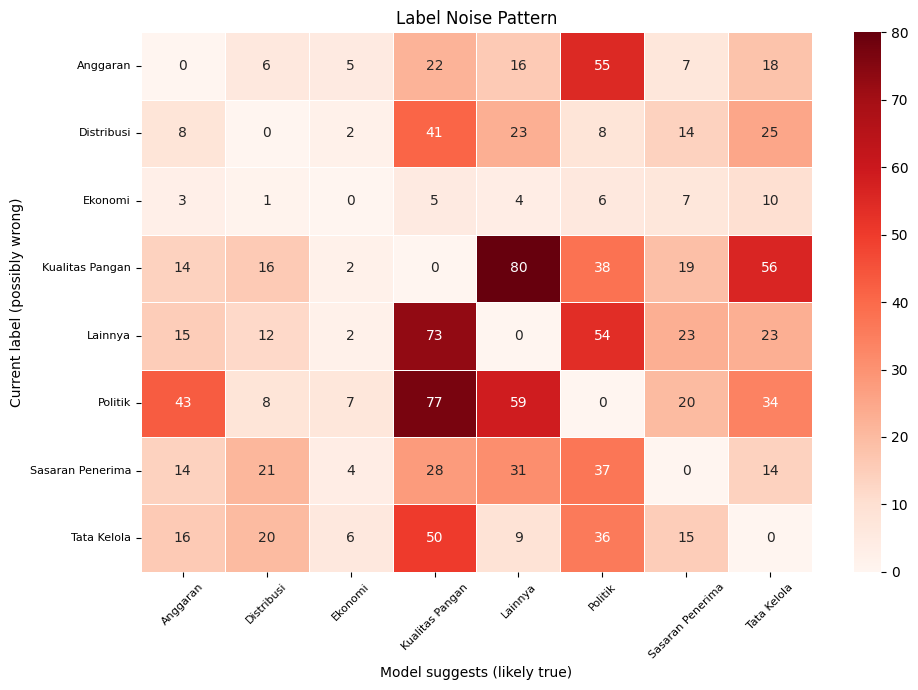

In [5]:
flagged_suggested = oof_probs[issue_indices].argmax(axis=1)
flagged_given     = labels[issue_indices]

confusion_noise = np.zeros((8, 8), dtype=int)
for g, s in zip(flagged_given, flagged_suggested):
    if g != s:
        confusion_noise[g][s] += 1

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(confusion_noise, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Model suggests (likely true)'); ax.set_ylabel('Current label (possibly wrong)')
ax.set_title('Label Noise Pattern')
ax.tick_params(axis='x', rotation=45, labelsize=8); ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout(); plt.show()

## Step 3 — Export Excel untuk Manual Review

In [6]:
self_conf = np.array([oof_probs[i, labels[i]] for i in range(len(labels))])

def get_top2(probs_row):
    idx = probs_row.argsort()[::-1]
    return le.classes_[idx[0]], round(float(probs_row[idx[0]]),3), le.classes_[idx[1]], round(float(probs_row[idx[1]]),3)

rows = []
for rank, idx in enumerate(issue_indices):
    t1, p1, t2, p2 = get_top2(oof_probs[idx])
    rows.append({
        'rank': rank+1, 'idx': int(idx),
        'full_text': labeled['full_text'].iloc[idx],
        'label_asli': le.classes_[labels[idx]],
        'self_confidence': round(float(self_conf[idx]), 4),
        'saran_1': t1, 'prob_1': p1,
        'saran_2': t2, 'prob_2': p2,
        'label_fix': '',
        'notes': '',
    })

review_df = pd.DataFrame(rows)
n_critical = (review_df['self_confidence'] < 0.3).sum()
print(f'Total flagged    : {len(review_df)}')
print(f'Sangat mencurigakan (conf<0.3): {n_critical}  <- review dulu')
review_df[['rank','label_asli','saran_1','prob_1','self_confidence']].head(10)

Total flagged    : 1262
Sangat mencurigakan (conf<0.3): 1224  <- review dulu


,rank,label_asli,saran_1,prob_1,self_confidence
0,1,Ekonomi,Tata Kelola,0.320,0.0000
1,2,Ekonomi,Lainnya,0.340,0.0000
2,3,Politik,Lainnya,0.893,0.0000
3,4,Lainnya,Anggaran,0.537,0.0000
4,5,Ekonomi,Politik,0.469,0.0008
5,6,Tata Kelola,Kualitas Pangan,0.524,0.0016
6,7,Distribusi,Kualitas Pangan,0.739,0.0019
7,8,Anggaran,Kualitas Pangan,0.650,0.0019
8,9,Ekonomi,Kualitas Pangan,0.660,0.0022
9,10,Anggaran,Lainnya,0.499,0.0022


In [7]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
review_path = OUTPUT_DIR / 'label_review.xlsx'
review_df.to_excel(review_path, index=False, engine='openpyxl')

wb = load_workbook(review_path); ws = wb.active; ws.title = 'Review'
hfill = PatternFill('solid', start_color='1F3864', end_color='1F3864')
hfont = Font(bold=True, color='FFFFFF', size=10)
for cell in ws[1]:
    cell.fill = hfill; cell.font = hfont
    cell.alignment = Alignment(horizontal='center', wrap_text=True)

dv = DataValidation(type='list',
    formula1='"' + ','.join(LABEL_ORDER) + '"', allow_blank=True)
ws.add_data_validation(dv); dv.sqref = f'J2:J{len(review_df)+1}'

red_fill    = PatternFill('solid', start_color='FFCDD2', end_color='FFCDD2')
orange_fill = PatternFill('solid', start_color='FFE0B2', end_color='FFE0B2')
yellow_fill = PatternFill('solid', start_color='FFF9C4', end_color='FFF9C4')
fix_fill    = PatternFill('solid', start_color='E8F5E9', end_color='E8F5E9')

for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    conf = row[4].value
    fill = red_fill if (conf and conf < 0.2) else orange_fill if (conf and conf < 0.35) else yellow_fill
    for cell in row: cell.fill = fill
    row[9].fill = fix_fill; row[9].alignment = Alignment(horizontal='center')

for col, w in [('A',6),('B',7),('C',60),('D',16),('E',16),
               ('F',16),('G',9),('H',16),('I',9),('J',18),('K',25)]:
    ws.column_dimensions[col].width = w
ws.freeze_panes = 'A2'
for cell in ws['C']: cell.alignment = Alignment(wrap_text=True, vertical='top')
for row in ws.iter_rows(min_row=2, max_row=ws.max_row):
    ws.row_dimensions[row[0].row].height = 45
ws.row_dimensions[1].height = 30
wb.save(review_path)
print(f'Saved: {review_path}')
print('Buka file, isi kolom label_fix (ada dropdown), lalu jalankan cell berikut.')

Saved: ..\data\outputs\label_review.xlsx
Buka file, isi kolom label_fix (ada dropdown), lalu jalankan cell berikut.


## Step 4 — Apply Fixes (jalankan setelah review selesai)

In [8]:
reviewed = pd.read_excel(OUTPUT_DIR / 'label_review.xlsx', sheet_name='Review')
filled   = reviewed[reviewed['label_fix'].notna() & (reviewed['label_fix'].astype(str).str.strip() != '')]
changed  = filled[filled['label_fix'].astype(str) != filled['label_asli'].astype(str)]
print(f'Total flagged: {len(reviewed)}  Diisi: {len(filled)}  Diubah: {len(changed)}')

labeled_clean = labeled.copy()
n_fixed = 0
for _, row in reviewed.iterrows():
    fix = str(row.get('label_fix','')).strip()
    if not fix or fix=='nan' or fix not in LABEL_ORDER: continue
    idx = int(row['idx'])
    if labeled_clean.at[idx,'label'] != fix:
        labeled_clean.at[idx,'label'] = fix; n_fixed += 1

print(f'Label diperbaiki: {n_fixed}')
clean_path = DATA_DIR / 'cleaned/labeled_clean.xlsx'
clean_path.parent.mkdir(exist_ok=True)
labeled_clean[['full_text','label']].to_excel(clean_path, index=False)
print(f'Saved: {clean_path}')

Total flagged: 1262  Diisi: 0  Diubah: 0
Label diperbaiki: 0
Saved: ..\data\cleaned\labeled_clean.xlsx
